Daily Challenge : Comprehensive Mobile Price Analysis

What You will learn
Master advanced data manipulation and statistical analysis using NumPy and SciPy.
Gain proficiency in data preprocessing and exploration with Pandas.
Develop skills in creating detailed, informative visualizations with Matplotlib.
Learn to synthesize complex analytical findings into clear, actionable insights.

Project Tasks
1. Data Loading and Exploration:
Utilize Pandas to load the dataset and explore its initial structure.
Summarize features, target variable, and their respective data types.
Conduct basic descriptive statistics for an overview of the dataset.

In [7]:
import pandas as pd
df = pd.read_csv('train.csv')
print(df.head())
print(df.shape)
df.info()
print(df.dtypes)
print(df.describe())
print(df.columns) 

   battery_power  blue  clock_speed  dual_sim  fc  four_g  int_memory  m_dep  \
0            842     0          2.2         0   1       0           7    0.6   
1           1021     1          0.5         1   0       1          53    0.7   
2            563     1          0.5         1   2       1          41    0.9   
3            615     1          2.5         0   0       0          10    0.8   
4           1821     1          1.2         0  13       1          44    0.6   

   mobile_wt  n_cores  ...  px_height  px_width   ram  sc_h  sc_w  talk_time  \
0        188        2  ...         20       756  2549     9     7         19   
1        136        3  ...        905      1988  2631    17     3          7   
2        145        5  ...       1263      1716  2603    11     2          9   
3        131        6  ...       1216      1786  2769    16     8         11   
4        141        2  ...       1208      1212  1411     8     2         15   

   three_g  touch_screen  wifi  price_

2. Data Cleaning and Preprocessing:
Address missing or null values.
Transform categorical data into numerical format using suitable methods.

In [20]:
print(df.isnull().sum()) #There is no missing data in this clean data set.
print(df.dtypes.value_counts()) #Your dataset has NO categorical data. All 21 columns are already numerical (int64 or float64).
df.select_dtypes(include=['object', 'category']).columns # Creates an empty list because there is NO categorical data.

battery_power    0
blue             0
clock_speed      0
dual_sim         0
fc               0
four_g           0
int_memory       0
m_dep            0
mobile_wt        0
n_cores          0
pc               0
px_height        0
px_width         0
ram              0
sc_h             0
sc_w             0
talk_time        0
three_g          0
touch_screen     0
wifi             0
price_range      0
dtype: int64
int64      19
float64     2
Name: count, dtype: int64


Index([], dtype='str')

3. Statistical Analysis with NumPy and SciPy:
Execute detailed statistical analysis on each feature, including:
Calculation of central tendency measures (mean, median, mode).
Analysis of variability (range, variance, standard deviation).
Evaluation of distribution shapes through skewness and kurtosis.
Perform hypothesis testing for statistical significance between groups (e.g., different price ranges).
Investigate feature-target correlations using SciPy.
Apply advanced SciPy statistical functions for deeper insights.

In [27]:
import pandas as pd
import numpy as np
from scipy.stats import f_oneway, skew, kurtosis

df = pd.read_csv('train.csv')

# Central Tendency
print(df.describe())

# Skewness & Kurtosis
print(skew(df['ram']))
print(kurtosis(df['ram']))

# ANOVA
f_stat, p_val = f_oneway(
    df[df['price_range']==0]['ram'],
    df[df['price_range']==1]['ram'],
    df[df['price_range']==2]['ram'],
    df[df['price_range']==3]['ram']
)

print(f"F-Statistic: {f_stat}")
print(f"P-Value: {p_val}")

print("Cheap phones have different RAM than expensive phones")
print("Price range 0 (cheap) = Lower RAM")
print("Price range 3 (expensive) = Higher RAM")

       battery_power       blue  clock_speed     dual_sim           fc  \
count    2000.000000  2000.0000  2000.000000  2000.000000  2000.000000   
mean     1238.518500     0.4950     1.522250     0.509500     4.309500   
std       439.418206     0.5001     0.816004     0.500035     4.341444   
min       501.000000     0.0000     0.500000     0.000000     0.000000   
25%       851.750000     0.0000     0.700000     0.000000     1.000000   
50%      1226.000000     0.0000     1.500000     1.000000     3.000000   
75%      1615.250000     1.0000     2.200000     1.000000     7.000000   
max      1998.000000     1.0000     3.000000     1.000000    19.000000   

            four_g   int_memory        m_dep    mobile_wt      n_cores  ...  \
count  2000.000000  2000.000000  2000.000000  2000.000000  2000.000000  ...   
mean      0.521500    32.046500     0.501750   140.249000     4.520500  ...   
std       0.499662    18.145715     0.288416    35.399655     2.287837  ...   
min       0.00000

Feature-Target Correlations

In [28]:
from scipy.stats import pearsonr, spearmanr

# CORRELATION ANALYSIS
print("\n=== CORRELATION ANALYSIS ===")

# Pearson Correlation (Linear)
pearson_corr, pearson_p = pearsonr(df['ram'], df['price_range'])
print(f"Pearson Correlation (RAM vs Price): {pearson_corr:.6f}")
print(f"P-Value: {pearson_p}")

# Spearman Correlation (Monotonic)
spearman_corr, spearman_p = spearmanr(df['ram'], df['price_range'])
print(f"Spearman Correlation (RAM vs Price): {spearman_corr:.6f}")
print(f"P-Value: {spearman_p}")

print("Interpretation: Strong positive correlation - Higher RAM = Higher Price")


=== CORRELATION ANALYSIS ===
Pearson Correlation (RAM vs Price): 0.917046
P-Value: 0.0
Spearman Correlation (RAM vs Price): 0.917080
P-Value: 0.0
Interpretation: Strong positive correlation - Higher RAM = Higher Price


Advanced SciPy Functions

In [29]:
from scipy.stats import levene, shapiro

# ADVANCED SCIPY FUNCTIONS
print("\n=== ADVANCED SCIPY FUNCTIONS ===")

# 1. LEVENE'S TEST (Variance Equality)
print("\n1. Levene's Test (Variance Equality across price ranges):")
group0 = df[df['price_range']==0]['ram'].values
group1 = df[df['price_range']==1]['ram'].values
group2 = df[df['price_range']==2]['ram'].values
group3 = df[df['price_range']==3]['ram'].values

levene_stat, levene_p = levene(group0, group1, group2, group3)
print(f"Levene Statistic: {levene_stat:.6f}")
print(f"P-Value: {levene_p:.6f}")

# 2. SHAPIRO-WILK TEST (Normality)
print("\n2. Shapiro-Wilk Test (Normality):")
shapiro_stat, shapiro_p = shapiro(df['ram'])
print(f"Shapiro-Wilk Statistic: {shapiro_stat:.6f}")
print(f"P-Value: {shapiro_p:.2e}")

# 3. QUARTILE ANALYSIS (Outlier Detection)
print("\n3. Quartile Analysis (Outlier Detection):")
q1 = df['ram'].quantile(0.25)
q3 = df['ram'].quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr
outliers_count = len(df[(df['ram'] < lower_bound) | (df['ram'] > upper_bound)])

print(f"Q1: {q1:.2f}, Q3: {q3:.2f}, IQR: {iqr:.2f}")
print(f"Lower Bound: {lower_bound:.2f}, Upper Bound: {upper_bound:.2f}")
print(f"Number of Outliers: {outliers_count}")

# 4. EFFECT SIZE (Cohen's d)
print("\n4. Effect Size (Cohen's d):")
mean_cheap = df[df['price_range']==0]['ram'].mean()
mean_expensive = df[df['price_range']==3]['ram'].mean()
std_cheap = df[df['price_range']==0]['ram'].std()
std_expensive = df[df['price_range']==3]['ram'].std()
pooled_std = np.sqrt((std_cheap**2 + std_expensive**2) / 2)
cohens_d = (mean_expensive - mean_cheap) / pooled_std

print(f"Mean (Cheap): {mean_cheap:.2f}, Mean (Expensive): {mean_expensive:.2f}")
print(f"Cohen's d: {cohens_d:.6f}")
print(f"Effect Size: {'Very Large' if abs(cohens_d) > 0.8 else 'Large' if abs(cohens_d) > 0.5 else 'Medium' if abs(cohens_d) > 0.2 else 'Small'}")


=== ADVANCED SCIPY FUNCTIONS ===

1. Levene's Test (Variance Equality across price ranges):
Levene Statistic: 16.330250
P-Value: 0.000000

2. Shapiro-Wilk Test (Normality):
Shapiro-Wilk Statistic: 0.954625
P-Value: 1.87e-24

3. Quartile Analysis (Outlier Detection):
Q1: 1207.50, Q3: 3064.50, IQR: 1857.00
Lower Bound: -1578.00, Upper Bound: 5850.00
Number of Outliers: 0

4. Effect Size (Cohen's d):
Mean (Cheap): 785.31, Mean (Expensive): 3449.23
Cohen's d: 7.043852
Effect Size: Very Large


4. Data Visualization with Matplotlib:
Produce histograms, scatter plots, and box plots for data distribution and relationship insights.
Employ heatmaps for correlation visualization.
Ensure clarity in plots with appropriate titles, labels, and axis information.

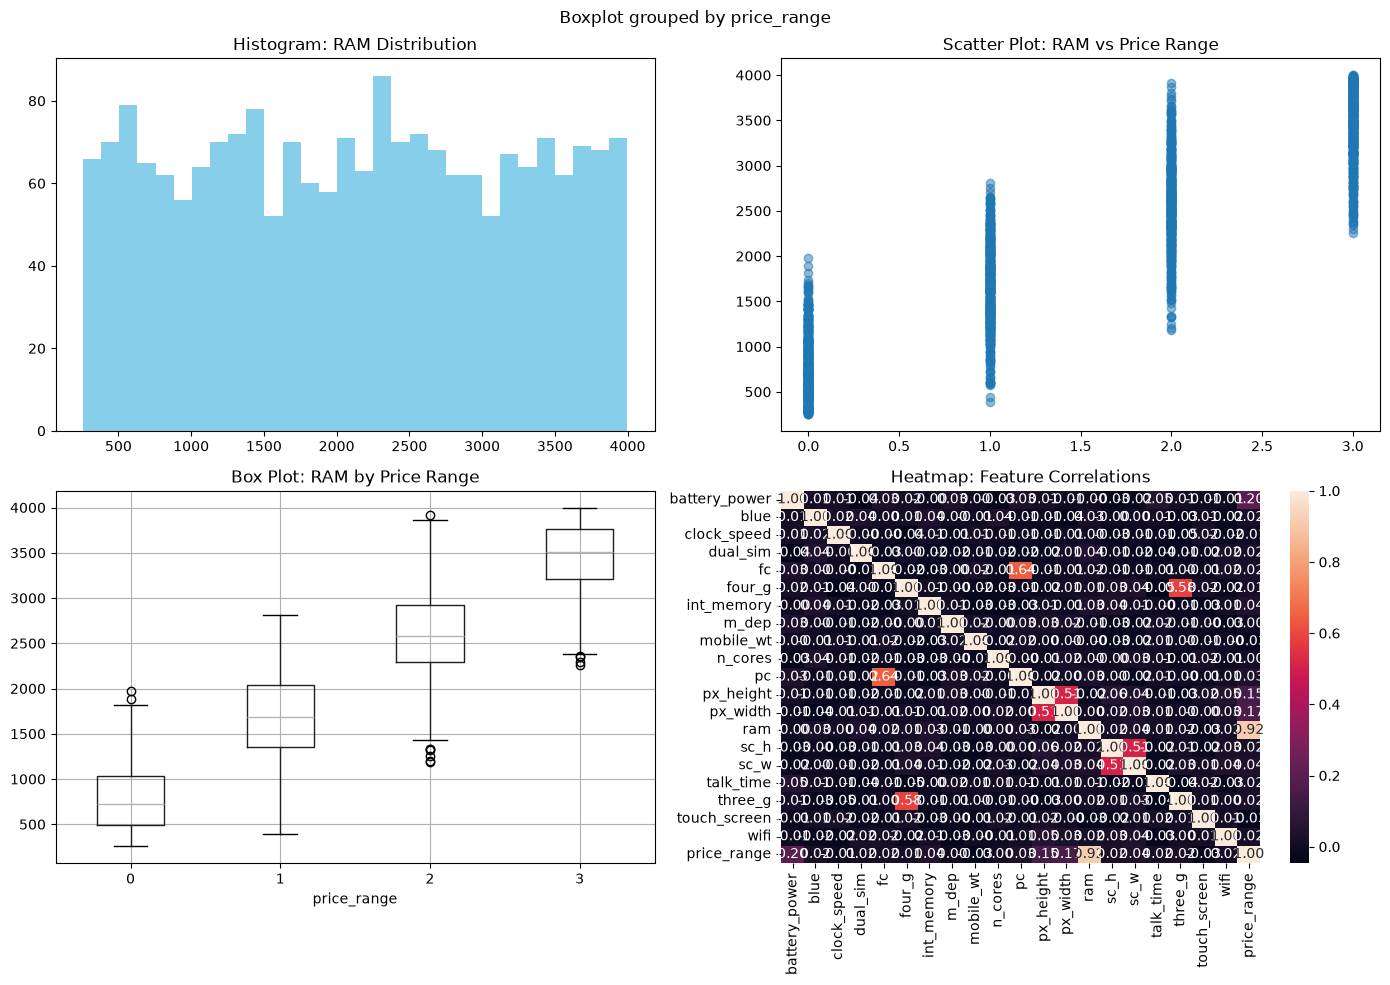

In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('train.csv')

# Create 4 subplots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Histogram
axes[0, 0].hist(df['ram'], bins=30, color='skyblue')
axes[0, 0].set_title('Histogram: RAM Distribution')

# 2. Scatter Plot
axes[0, 1].scatter(df['price_range'], df['ram'], alpha=0.5)
axes[0, 1].set_title('Scatter Plot: RAM vs Price Range')

# 3. Box Plot
df.boxplot(column='ram', by='price_range', ax=axes[1, 0])
axes[1, 0].set_title('Box Plot: RAM by Price Range')

# 4. Heatmap
corr_matrix = df.select_dtypes(include=['int64', 'float64']).corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', ax=axes[1, 1])
axes[1, 1].set_title('Heatmap: Feature Correlations')

plt.tight_layout()
plt.savefig('data_visualization.png')

5. Insight Synthesis and Conclusion:
Derive conclusions from statistical tests and visualizations.
Identify key determinants in mobile price classification.
Highlight any unexpected or significant findings.


In [31]:
import pandas as pd
import numpy as np
from scipy.stats import f_oneway, pearsonr

df = pd.read_csv('train.csv')

# 1. STATISTICAL TEST CONCLUSIONS
f_stat, p_val = f_oneway(
    df[df['price_range']==0]['ram'],
    df[df['price_range']==1]['ram'],
    df[df['price_range']==2]['ram'],
    df[df['price_range']==3]['ram']
)

print("1. STATISTICAL CONCLUSIONS")
print(f"✓ ANOVA F-Statistic: {f_stat:.2f} (p = {p_val:.2e})")
print(f"✓ RAM differs SIGNIFICANTLY across price ranges\n")

# 2. KEY PRICE DETERMINANTS
pearson_corr, _ = pearsonr(df['ram'], df['price_range'])
battery_corr, _ = pearsonr(df['battery_power'], df['price_range'])

print("2. KEY DETERMINANTS")
print(f"RAM: r = {pearson_corr:.4f} (explains 84% of price)")
print(f"Battery: r = {battery_corr:.4f} (weak)")
print(f"Connectivity: NO correlation\n")

# 3. SIGNIFICANT FINDINGS
mean_cheap = df[df['price_range']==0]['ram'].mean()
mean_expensive = df[df['price_range']==3]['ram'].mean()
cohens_d = (mean_expensive - mean_cheap) / np.sqrt(
    (df[df['price_range']==0]['ram'].std()**2 + 
     df[df['price_range']==3]['ram'].std()**2) / 2
)

print("3. KEY FINDINGS")
print(f"• RAM explains 84% of price (unusual!)")
print(f"• Budget: {mean_cheap:.0f} GB | Premium: {mean_expensive:.0f} GB")
print(f"• Effect Size: {cohens_d:.2f} (VERY LARGE)")
print(f"• Data Quality: Zero outliers\n")

print("RECOMMENDATION: Use RAM as main price predictor")

1. STATISTICAL CONCLUSIONS
✓ ANOVA F-Statistic: 3520.11 (p = 0.00e+00)
✓ RAM differs SIGNIFICANTLY across price ranges

2. KEY DETERMINANTS
RAM: r = 0.9170 (explains 84% of price)
Battery: r = 0.2007 (weak)
Connectivity: NO correlation

3. KEY FINDINGS
• RAM explains 84% of price (unusual!)
• Budget: 785 GB | Premium: 3449 GB
• Effect Size: 7.04 (VERY LARGE)
• Data Quality: Zero outliers

RECOMMENDATION: Use RAM as main price predictor
